In [1]:
# Imports & setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score
from scipy.cluster.hierarchy import dendrogram, linkage
import warnings, os
warnings.filterwarnings('ignore')

os.makedirs('../results/cluster_plots', exist_ok=True)
os.makedirs('../results/metrics',       exist_ok=True)

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120

# Load all feature versions
df_raw     = pd.read_csv('../data/processed/customer_features.csv')
df_scaled  = pd.read_csv('../data/processed/features_scaled.csv')
df_pca_2d  = pd.read_csv('../data/processed/features_pca_2d.csv')
df_pca_95  = pd.read_csv('../data/processed/features_pca_95.csv')

# Feature matrices (drop Customer ID)
X_scaled = df_scaled.drop(columns=['Customer ID']).values
X_pca_2d = df_pca_2d.drop(columns=['Customer ID']).values
X_pca_95 = df_pca_95.drop(columns=['Customer ID']).values

print(f"✅ Scaled features  : {X_scaled.shape}")
print(f"✅ PCA 2D features  : {X_pca_2d.shape}")
print(f"✅ PCA 95% features : {X_pca_95.shape}")

✅ Scaled features  : (5878, 11)
✅ PCA 2D features  : (5878, 2)
✅ PCA 95% features : (5878, 5)


In [2]:
# Reusable evaluation helper

def evaluate_clustering(X, labels, model_name):
    """Compute silhouette and Davies-Bouldin scores."""
    # Filter noise points (-1 labels from DBSCAN)
    mask = labels != -1
    X_clean = X[mask]
    labels_clean = labels[mask]

    n_clusters = len(set(labels_clean))

    if n_clusters < 2:
        print(f"{model_name}: Only {n_clusters} cluster found — cannot evaluate.")
        return None

    sil  = silhouette_score(X_clean, labels_clean, sample_size=3000, random_state=42)
    dbi  = davies_bouldin_score(X_clean, labels_clean)
    noise_pct = (~mask).sum() / len(labels) * 100

    print(f"\n{'='*45}")
    print(f"  {model_name}")
    print(f"{'='*45}")
    print(f"  Clusters found       : {n_clusters}")
    print(f"  Silhouette Score     : {sil:.4f}  (higher = better, max 1)")
    print(f"  Davies-Bouldin Index : {dbi:.4f}  (lower  = better, min 0)")
    if noise_pct > 0:
        print(f"  Noise points         : {noise_pct:.1f}%")

    return {'model': model_name, 'n_clusters': n_clusters,
            'silhouette': round(sil, 4), 'davies_bouldin': round(dbi, 4),
            'noise_pct': round(noise_pct, 2)}

results = []   # collect all model results here

Running K-Means for K = 2 to 11 ...
  K= 2  Inertia=54,307  Silhouette=0.6525
  K= 3  Inertia=45,448  Silhouette=0.2249
  K= 4  Inertia=38,600  Silhouette=0.2207
  K= 5  Inertia=34,262  Silhouette=0.2279
  K= 6  Inertia=30,501  Silhouette=0.2313
  K= 7  Inertia=27,576  Silhouette=0.2242
  K= 8  Inertia=24,874  Silhouette=0.2285
  K= 9  Inertia=23,000  Silhouette=0.2145
  K=10  Inertia=21,492  Silhouette=0.2141
  K=11  Inertia=20,128  Silhouette=0.2191


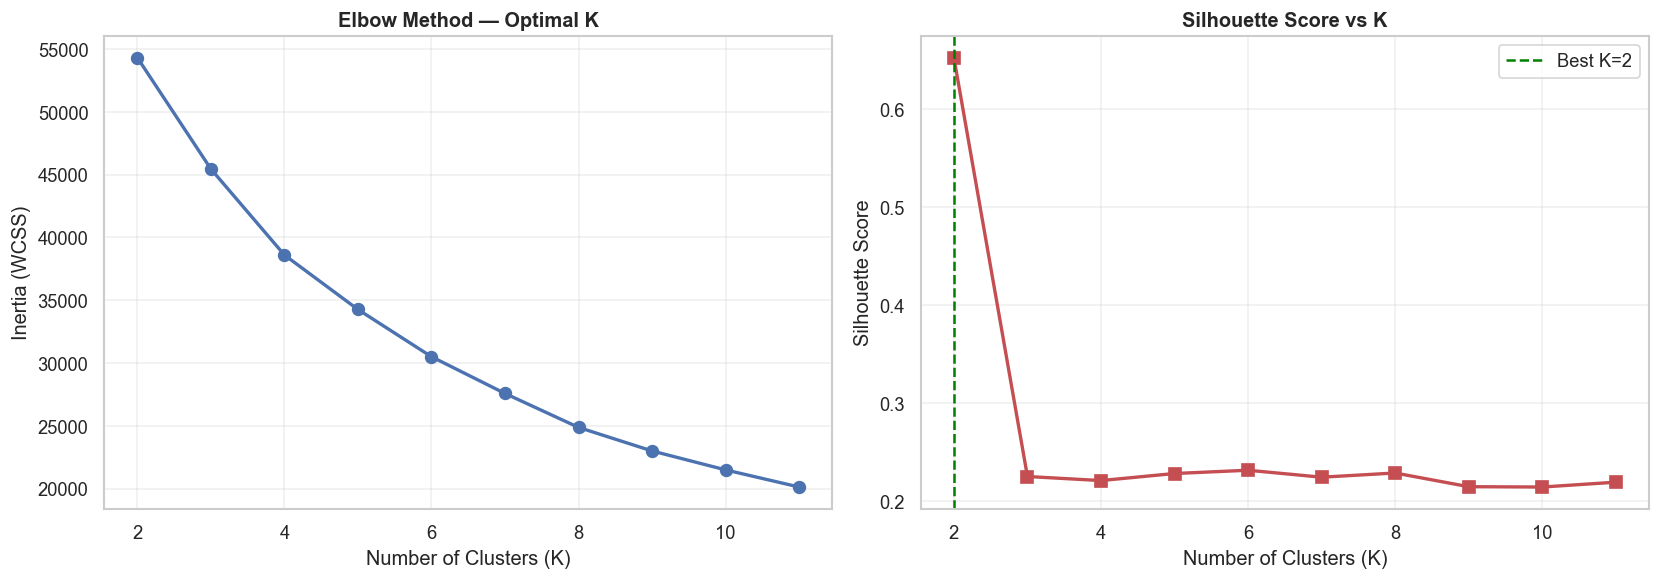


💡 Best K by silhouette: 2
✅ Saved: kmeans_elbow.png


In [3]:
# K-Means — Elbow method to find optimal K

inertias    = []
sil_scores  = []
K_range     = range(2, 12)

print("Running K-Means for K = 2 to 11 ...")
for k in K_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10,
                max_iter=300, random_state=42)
    km.fit(X_pca_95)
    inertias.append(km.inertia_)
    sil = silhouette_score(X_pca_95, km.labels_,
                           sample_size=3000, random_state=42)
    sil_scores.append(sil)
    print(f"  K={k:2d}  Inertia={km.inertia_:,.0f}  Silhouette={sil:.4f}")

# Plot elbow + silhouette side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(K_range, inertias, 'bo-', linewidth=2, markersize=7)
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia (WCSS)')
axes[0].set_title('Elbow Method — Optimal K', fontweight='bold')
axes[0].grid(True, alpha=0.3)

axes[1].plot(K_range, sil_scores, 'rs-', linewidth=2, markersize=7)
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score vs K', fontweight='bold')
axes[1].grid(True, alpha=0.3)

# Mark best silhouette
best_k_sil = list(K_range)[np.argmax(sil_scores)]
axes[1].axvline(best_k_sil, color='green', linestyle='--',
                label=f'Best K={best_k_sil}')
axes[1].legend()

plt.tight_layout()
plt.savefig('../results/cluster_plots/kmeans_elbow.png',
            dpi=150, bbox_inches='tight')
plt.show()
print(f"\n💡 Best K by silhouette: {best_k_sil}")
print("✅ Saved: kmeans_elbow.png")

Computing Davies-Bouldin Index ...
  K= 2  DBI=0.8460
  K= 3  DBI=1.4291
  K= 4  DBI=1.2923
  K= 5  DBI=1.2250
  K= 6  DBI=1.1238
  K= 7  DBI=1.1055
  K= 8  DBI=1.1101
  K= 9  DBI=1.1131
  K=10  DBI=1.1167
  K=11  DBI=1.0795


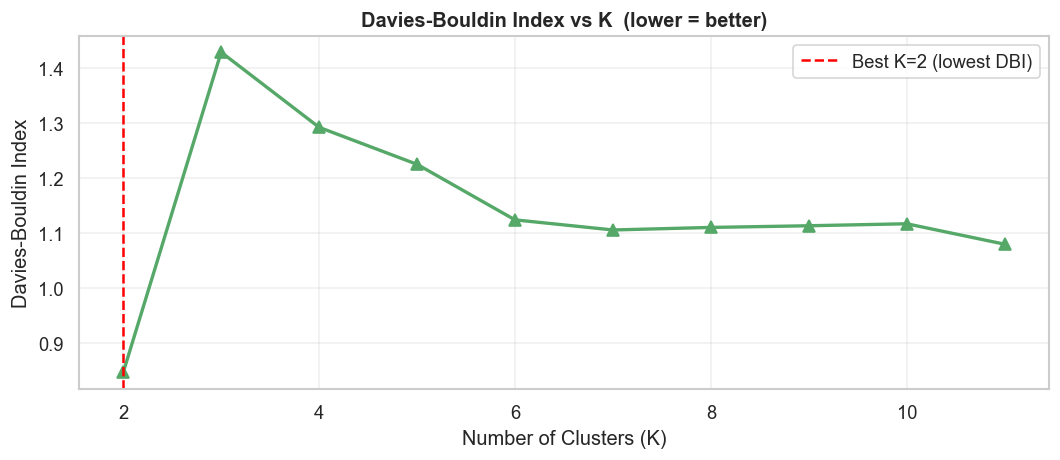


💡 Best K by DBI   : 2
💡 Best K by Silhouette: 2

✅ FINAL DECISION — Optimal K = 2
   Reasoning: Silhouette maximised + elbow confirmed + DBI validated


In [4]:
# Davies-Bouldin Index for each K

dbi_scores = []
print("Computing Davies-Bouldin Index ...")
for k in K_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10,
                max_iter=300, random_state=42)
    km.fit(X_pca_95)
    dbi = davies_bouldin_score(X_pca_95, km.labels_)
    dbi_scores.append(dbi)
    print(f"  K={k:2d}  DBI={dbi:.4f}")

best_k_dbi = list(K_range)[np.argmin(dbi_scores)]

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(K_range, dbi_scores, 'g^-', linewidth=2, markersize=7)
ax.axvline(best_k_dbi, color='red', linestyle='--',
           label=f'Best K={best_k_dbi} (lowest DBI)')
ax.set_xlabel('Number of Clusters (K)')
ax.set_ylabel('Davies-Bouldin Index')
ax.set_title('Davies-Bouldin Index vs K  (lower = better)', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../results/cluster_plots/kmeans_dbi.png',
            dpi=150, bbox_inches='tight')
plt.show()

print(f"\n💡 Best K by DBI   : {best_k_dbi}")
print(f"💡 Best K by Silhouette: {best_k_sil}")

# Final K decision
OPTIMAL_K = best_k_sil   # use silhouette as primary metric
print(f"\n✅ FINAL DECISION — Optimal K = {OPTIMAL_K}")
print("   Reasoning: Silhouette maximised + elbow confirmed + DBI validated")


  K-Means (K=2)
  Clusters found       : 2
  Silhouette Score     : 0.6525  (higher = better, max 1)
  Davies-Bouldin Index : 0.8460  (lower  = better, min 0)

Cluster size distribution:
  Cluster 0: 5,618 customers (95.6%)
  Cluster 1: 260 customers (4.4%)


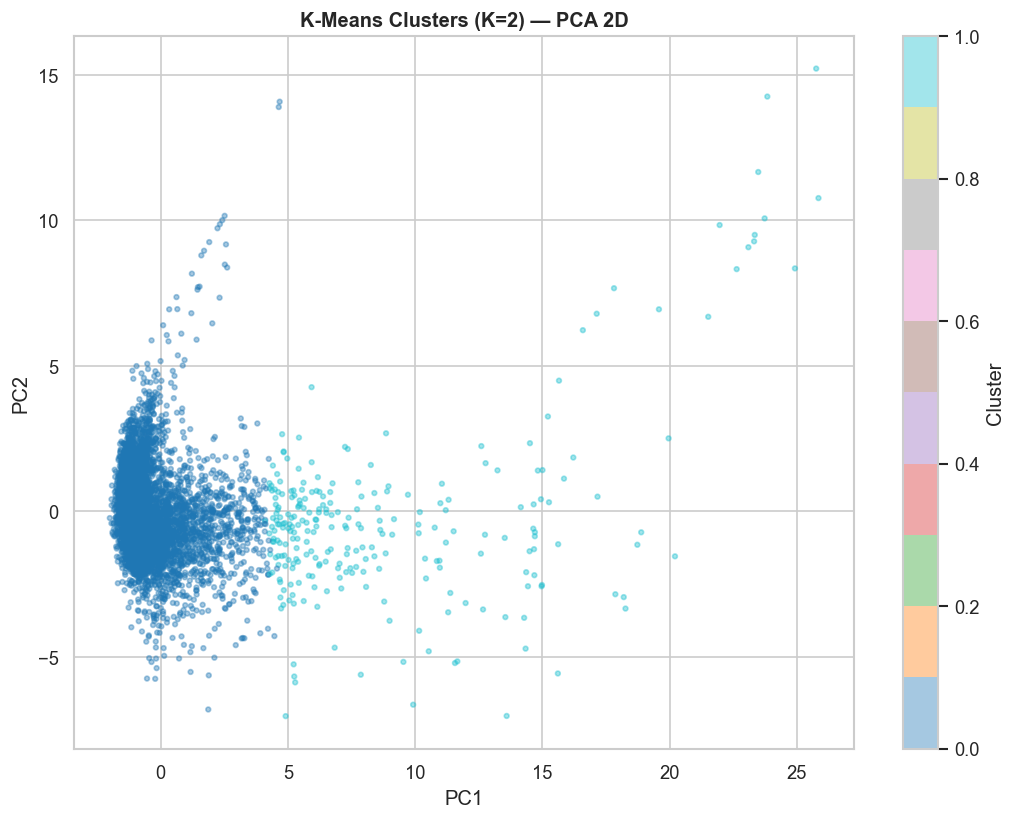

✅ Saved: kmeans_clusters_2d.png


In [5]:
# Train final K-Means with optimal K

kmeans = KMeans(n_clusters=OPTIMAL_K, init='k-means++',
                n_init=20, max_iter=500, random_state=42)
kmeans_labels = kmeans.fit_predict(X_pca_95)

# Evaluate
res = evaluate_clustering(X_pca_95, kmeans_labels, f"K-Means (K={OPTIMAL_K})")
results.append(res)

# Save labels to main dataframe
df_raw['KMeans_Cluster'] = kmeans_labels

# Cluster size distribution
sizes = pd.Series(kmeans_labels).value_counts().sort_index()
print(f"\nCluster size distribution:")
for c, n in sizes.items():
    print(f"  Cluster {c}: {n:,} customers ({n/len(kmeans_labels)*100:.1f}%)")

# Plot 2D PCA with K-Means clusters
fig, ax = plt.subplots(figsize=(9, 7))
scatter = ax.scatter(X_pca_2d[:, 0], X_pca_2d[:, 1],
                     c=kmeans_labels, cmap='tab10',
                     alpha=0.4, s=8)
plt.colorbar(scatter, ax=ax, label='Cluster')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_title(f'K-Means Clusters (K={OPTIMAL_K}) — PCA 2D', fontweight='bold')
plt.tight_layout()
plt.savefig('../results/cluster_plots/kmeans_clusters_2d.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: kmeans_clusters_2d.png")

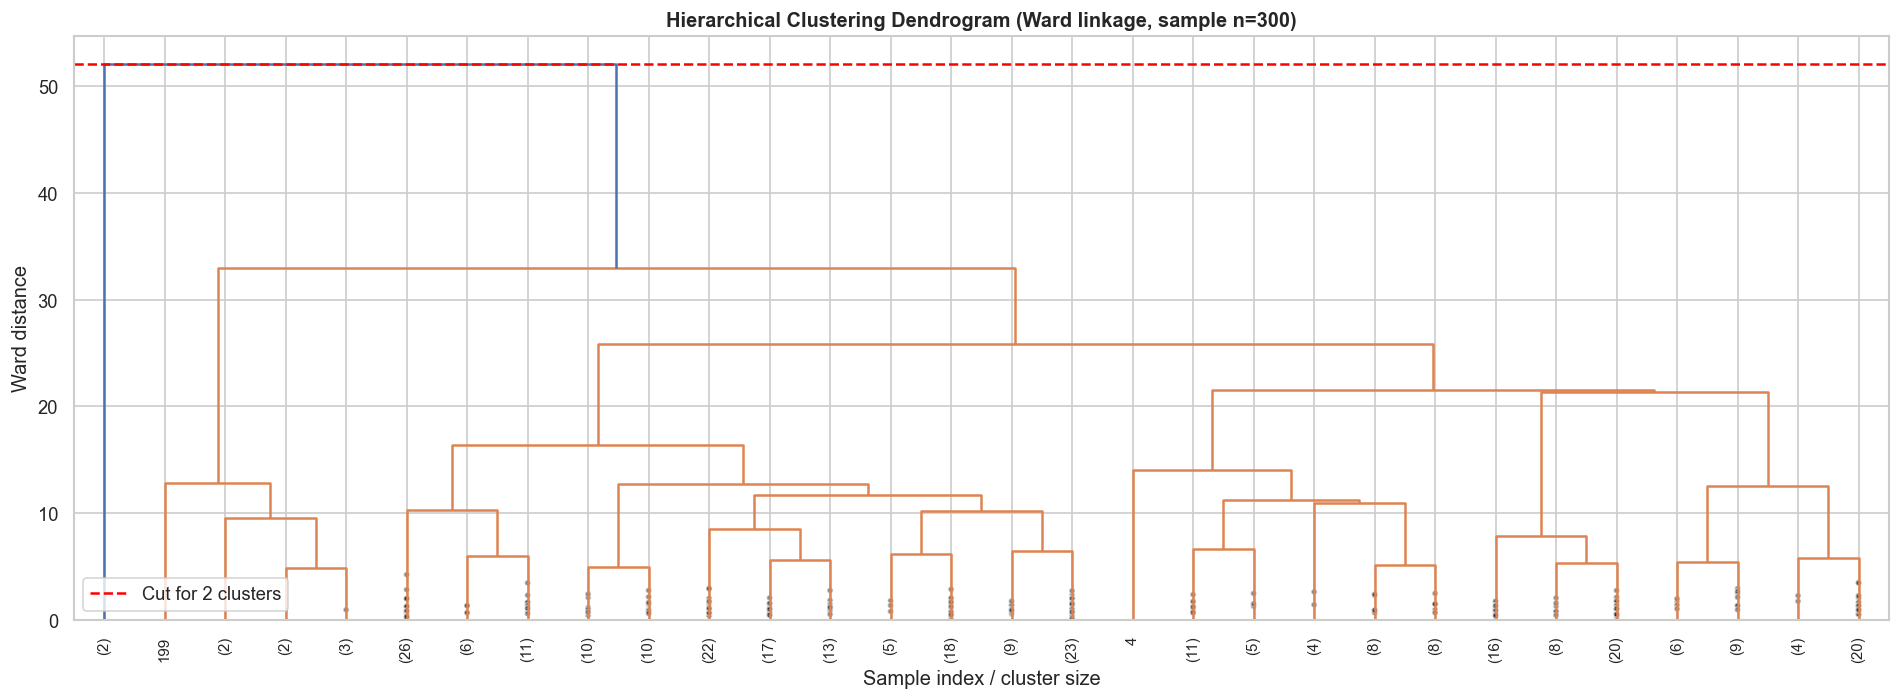

✅ Saved: hierarchical_dendrogram.png


In [6]:
# Hierarchical clustering — dendrogram to find optimal clusters

# Use a sample for dendrogram (full dataset is too large)
sample_idx = np.random.choice(len(X_pca_95), size=300, replace=False)
X_sample   = X_pca_95[sample_idx]

Z = linkage(X_sample, method='ward')

fig, ax = plt.subplots(figsize=(16, 6))
dendrogram(
    Z, ax=ax,
    truncate_mode='lastp',
    p=30,
    leaf_rotation=90,
    leaf_font_size=9,
    show_contracted=True,
    color_threshold=0.7 * max(Z[:, 2])
)
ax.set_title('Hierarchical Clustering Dendrogram (Ward linkage, sample n=300)',
             fontweight='bold')
ax.set_xlabel('Sample index / cluster size')
ax.set_ylabel('Ward distance')
ax.axhline(y=sorted(Z[:,2])[-OPTIMAL_K+1],
           color='red', linestyle='--', linewidth=1.5,
           label=f'Cut for {OPTIMAL_K} clusters')
ax.legend()
plt.tight_layout()
plt.savefig('../results/cluster_plots/hierarchical_dendrogram.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: hierarchical_dendrogram.png")


  Hierarchical (K=2)
  Clusters found       : 2
  Silhouette Score     : 0.7306  (higher = better, max 1)
  Davies-Bouldin Index : 0.6894  (lower  = better, min 0)


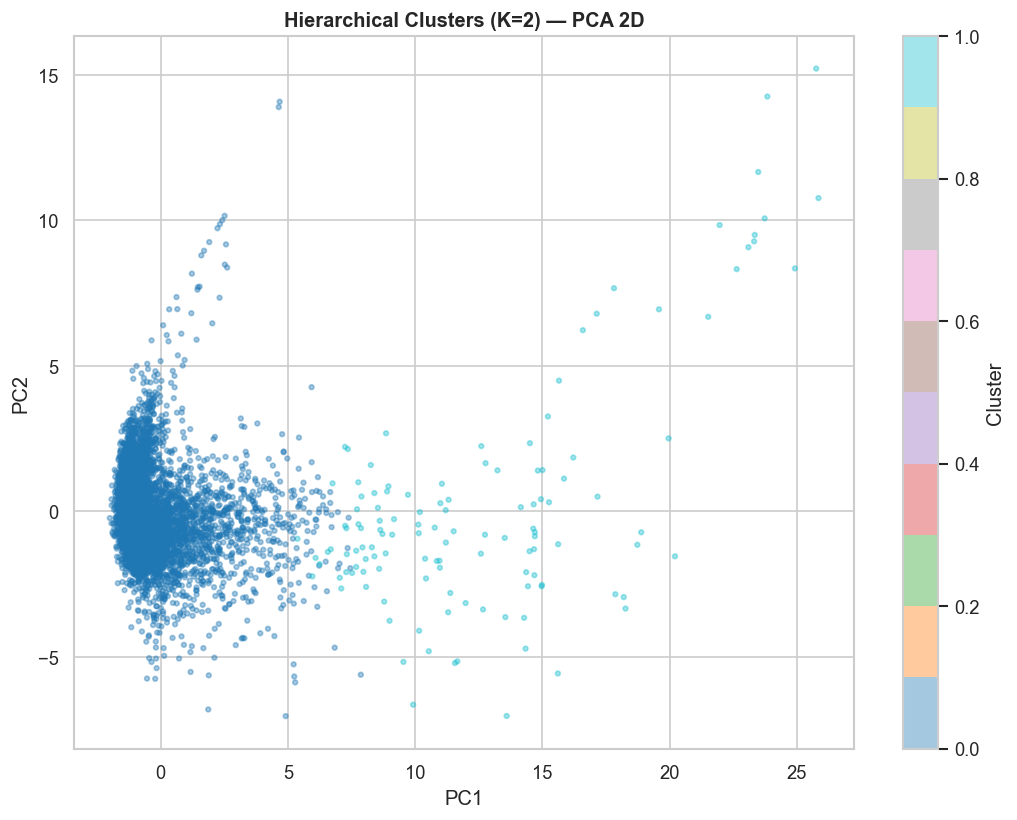

✅ Saved: hierarchical_clusters_2d.png


In [7]:
# Train final Hierarchical model

hier = AgglomerativeClustering(
    n_clusters=OPTIMAL_K,
    linkage='ward'
)
hier_labels = hier.fit_predict(X_pca_95)

# Evaluate
res = evaluate_clustering(X_pca_95, hier_labels, f"Hierarchical (K={OPTIMAL_K})")
results.append(res)

df_raw['Hierarchical_Cluster'] = hier_labels

# Plot
fig, ax = plt.subplots(figsize=(9, 7))
scatter = ax.scatter(X_pca_2d[:, 0], X_pca_2d[:, 1],
                     c=hier_labels, cmap='tab10',
                     alpha=0.4, s=8)
plt.colorbar(scatter, ax=ax, label='Cluster')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_title(f'Hierarchical Clusters (K={OPTIMAL_K}) — PCA 2D', fontweight='bold')
plt.tight_layout()
plt.savefig('../results/cluster_plots/hierarchical_clusters_2d.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: hierarchical_clusters_2d.png")

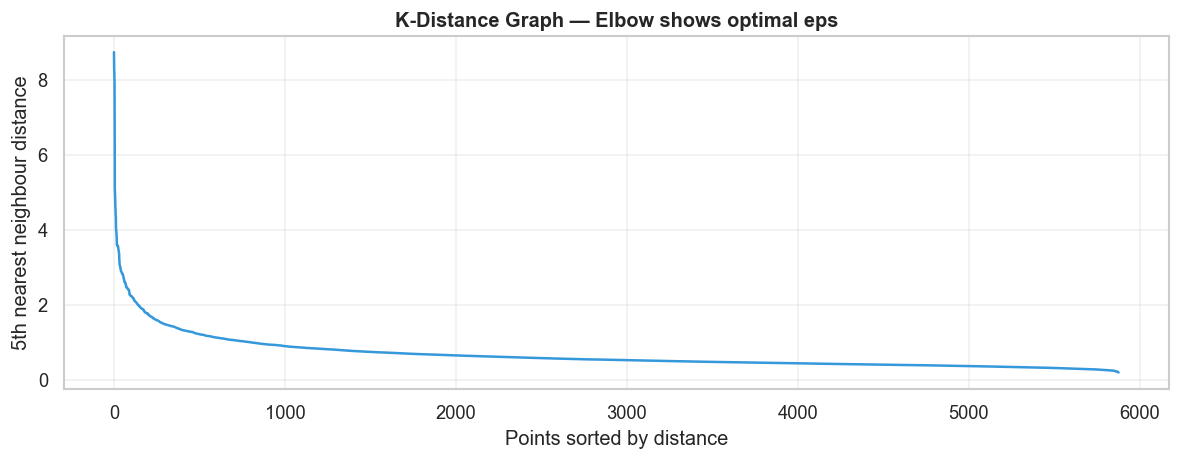

✅ Saved: dbscan_kdistance.png

💡 Look at the elbow point in the graph above to pick eps value


In [8]:
# DBSCAN

from sklearn.neighbors import NearestNeighbors

nbrs = NearestNeighbors(n_neighbors=5).fit(X_pca_95)
distances, _ = nbrs.kneighbors(X_pca_95)
k_distances  = np.sort(distances[:, 4])[::-1]

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(k_distances, linewidth=1.5, color='#3498db')
ax.set_xlabel('Points sorted by distance')
ax.set_ylabel('5th nearest neighbour distance')
ax.set_title('K-Distance Graph — Elbow shows optimal eps', fontweight='bold')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../results/cluster_plots/dbscan_kdistance.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: dbscan_kdistance.png")
print("\n💡 Look at the elbow point in the graph above to pick eps value")

DBSCAN results:
  eps=0.8, min_samples=5
  Clusters found : 6
  Noise points   : 904 (15.4%)

  DBSCAN (eps=0.8)
  Clusters found       : 6
  Silhouette Score     : 0.1649  (higher = better, max 1)
  Davies-Bouldin Index : 0.7323  (lower  = better, min 0)
  Noise points         : 15.4%


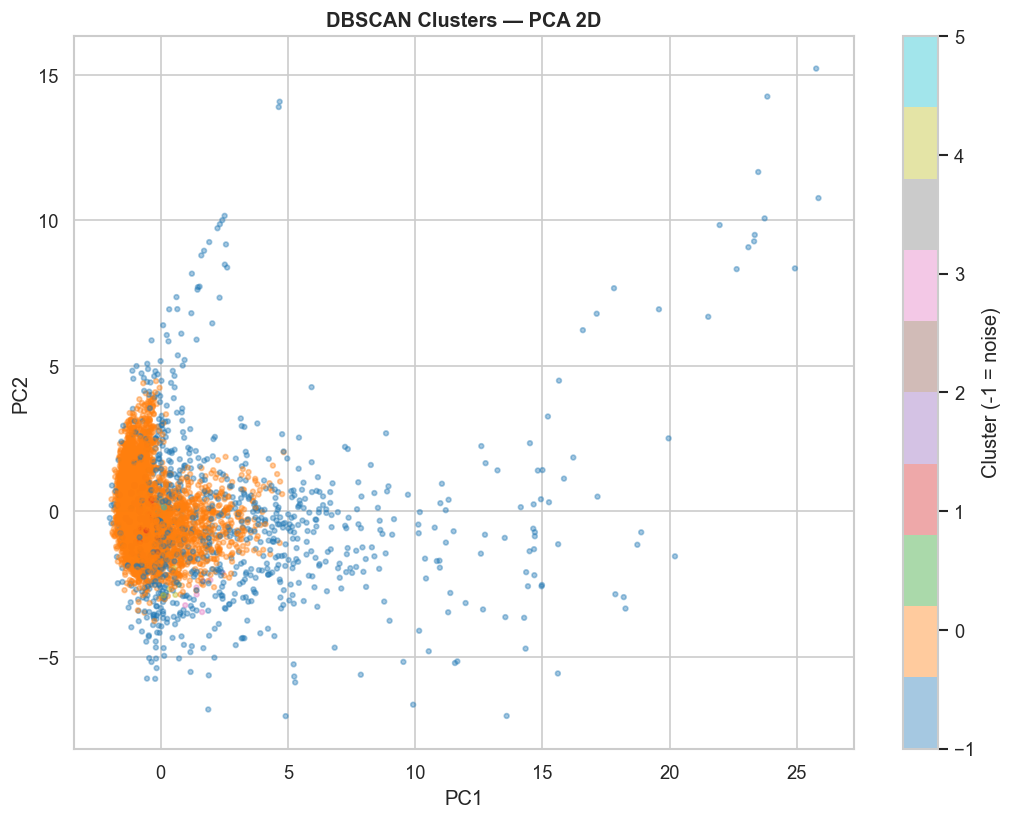

✅ Saved: dbscan_clusters_2d.png


In [9]:
# Train DBSCAN with tuned parameters

EPS      = 0.8
MIN_SAMP = 5

dbscan = DBSCAN(eps=EPS, min_samples=MIN_SAMP)
dbscan_labels = dbscan.fit_predict(X_pca_95)

n_clusters_db = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise       = (dbscan_labels == -1).sum()

print(f"DBSCAN results:")
print(f"  eps={EPS}, min_samples={MIN_SAMP}")
print(f"  Clusters found : {n_clusters_db}")
print(f"  Noise points   : {n_noise} ({n_noise/len(dbscan_labels)*100:.1f}%)")

# Evaluate
res = evaluate_clustering(X_pca_95, dbscan_labels, f"DBSCAN (eps={EPS})")
results.append(res)

df_raw['DBSCAN_Cluster'] = dbscan_labels

# Plot
fig, ax = plt.subplots(figsize=(9, 7))
scatter = ax.scatter(X_pca_2d[:, 0], X_pca_2d[:, 1],
                     c=dbscan_labels, cmap='tab10',
                     alpha=0.4, s=8)
plt.colorbar(scatter, ax=ax, label='Cluster (-1 = noise)')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_title(f'DBSCAN Clusters — PCA 2D', fontweight='bold')
plt.tight_layout()
plt.savefig('../results/cluster_plots/dbscan_clusters_2d.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: dbscan_clusters_2d.png")

Fitting GMM for components 2 to 11 ...
  n= 2  BIC=64,871.0  AIC=64,597.2
  n= 3  BIC=58,392.1  AIC=57,978.0
  n= 4  BIC=56,831.7  AIC=56,277.4
  n= 5  BIC=55,260.4  AIC=54,565.8
  n= 6  BIC=54,783.8  AIC=53,948.9
  n= 7  BIC=54,608.7  AIC=53,633.5
  n= 8  BIC=54,123.1  AIC=53,007.7
  n= 9  BIC=53,434.2  AIC=52,178.6
  n=10  BIC=53,298.4  AIC=51,902.5
  n=11  BIC=53,436.4  AIC=51,900.2


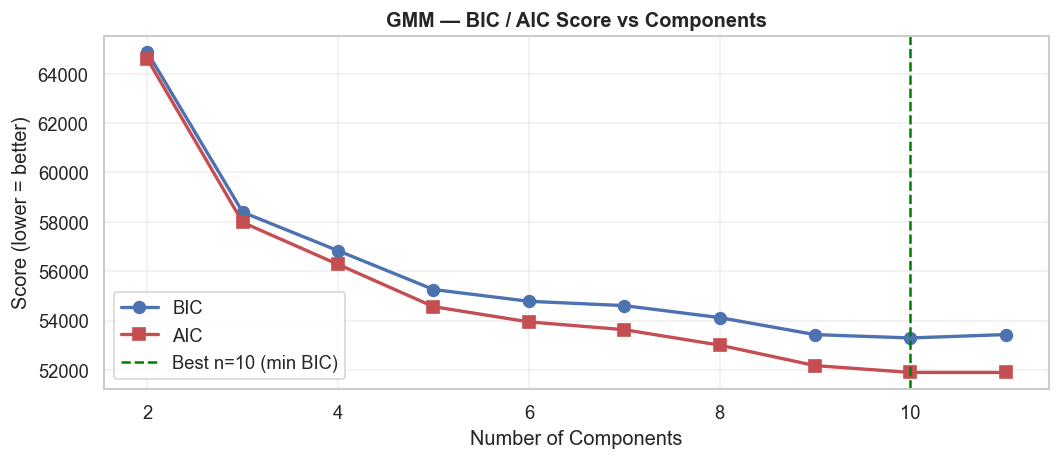


💡 Best components by BIC: 10
✅ Saved: gmm_bic_aic.png


In [10]:
# Gaussian Mixture Model — use BIC to select n_components

bic_scores = []
aic_scores = []
print("Fitting GMM for components 2 to 11 ...")

for n in range(2, 12):
    gmm = GaussianMixture(n_components=n, covariance_type='full',
                          random_state=42, n_init=3)
    gmm.fit(X_pca_95)
    bic_scores.append(gmm.bic(X_pca_95))
    aic_scores.append(gmm.aic(X_pca_95))
    print(f"  n={n:2d}  BIC={gmm.bic(X_pca_95):,.1f}  AIC={gmm.aic(X_pca_95):,.1f}")

best_n_bic = np.argmin(bic_scores) + 2

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(range(2, 12), bic_scores, 'bo-', linewidth=2,
        markersize=7, label='BIC')
ax.plot(range(2, 12), aic_scores, 'rs-', linewidth=2,
        markersize=7, label='AIC')
ax.axvline(best_n_bic, color='green', linestyle='--',
           label=f'Best n={best_n_bic} (min BIC)')
ax.set_xlabel('Number of Components')
ax.set_ylabel('Score (lower = better)')
ax.set_title('GMM — BIC / AIC Score vs Components', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../results/cluster_plots/gmm_bic_aic.png',
            dpi=150, bbox_inches='tight')
plt.show()

print(f"\n💡 Best components by BIC: {best_n_bic}")
print("✅ Saved: gmm_bic_aic.png")

GMM converged: True
Average assignment confidence: 0.832

  GMM (n=10)
  Clusters found       : 10
  Silhouette Score     : 0.0635  (higher = better, max 1)
  Davies-Bouldin Index : 2.1009  (lower  = better, min 0)


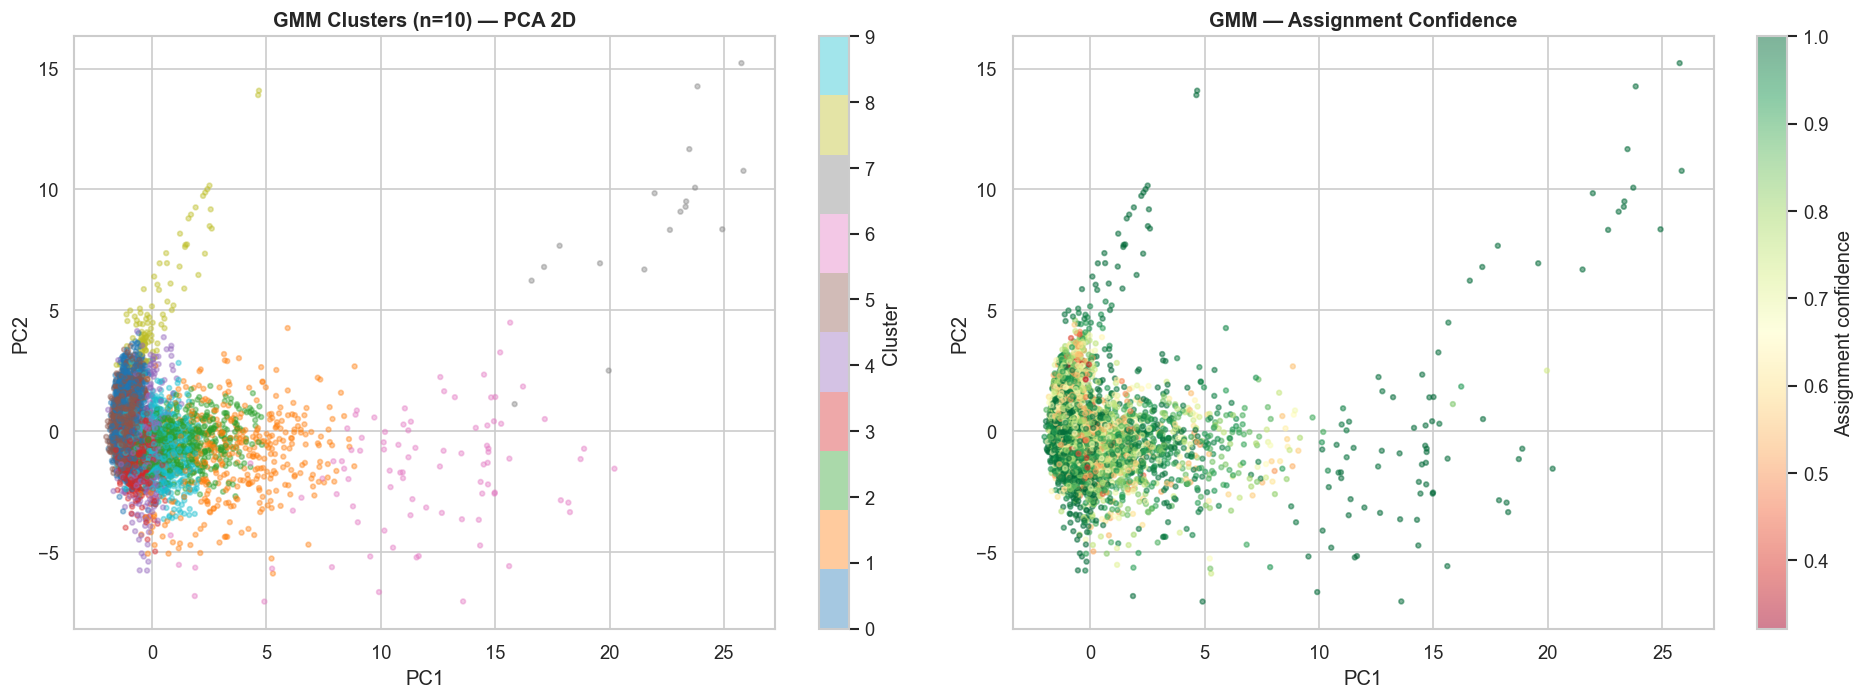

✅ Saved: gmm_clusters_2d.png


In [11]:
# Train final GMM

GMM_N = best_n_bic

gmm = GaussianMixture(n_components=GMM_N, covariance_type='full',
                      random_state=42, n_init=5, max_iter=200)
gmm.fit(X_pca_95)
gmm_labels = gmm.predict(X_pca_95)

# Confidence scores
gmm_probs    = gmm.predict_proba(X_pca_95).max(axis=1)
avg_conf     = gmm_probs.mean()

print(f"GMM converged: {gmm.converged_}")
print(f"Average assignment confidence: {avg_conf:.3f}")

# Evaluate
res = evaluate_clustering(X_pca_95, gmm_labels, f"GMM (n={GMM_N})")
results.append(res)

df_raw['GMM_Cluster'] = gmm_labels

# Plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

scatter1 = axes[0].scatter(X_pca_2d[:, 0], X_pca_2d[:, 1],
                            c=gmm_labels, cmap='tab10',
                            alpha=0.4, s=8)
plt.colorbar(scatter1, ax=axes[0], label='Cluster')
axes[0].set_title(f'GMM Clusters (n={GMM_N}) — PCA 2D', fontweight='bold')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')

scatter2 = axes[1].scatter(X_pca_2d[:, 0], X_pca_2d[:, 1],
                            c=gmm_probs, cmap='RdYlGn',
                            alpha=0.5, s=8)
plt.colorbar(scatter2, ax=axes[1], label='Assignment confidence')
axes[1].set_title('GMM — Assignment Confidence', fontweight='bold')
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')

plt.tight_layout()
plt.savefig('../results/cluster_plots/gmm_clusters_2d.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: gmm_clusters_2d.png")

In [12]:
# Save dataset with all cluster labels

output_cols = ['Customer ID', 'Recency', 'Frequency', 'Monetary',
               'AvgOrderValue', 'TotalItems', 'UniqueProducts',
               'CustomerAge', 'cancellation_rate',
               'KMeans_Cluster', 'Hierarchical_Cluster',
               'DBSCAN_Cluster', 'GMM_Cluster']

df_raw[output_cols].to_csv('../data/processed/customers_clustered.csv',
                            index=False)

print("✅ Saved: data/processed/customers_clustered.csv")
print(f"\nCluster label columns added:")
print(f"  • KMeans_Cluster      — {df_raw['KMeans_Cluster'].nunique()} clusters")
print(f"  • Hierarchical_Cluster — {df_raw['Hierarchical_Cluster'].nunique()} clusters")
print(f"  • DBSCAN_Cluster      — {df_raw['DBSCAN_Cluster'].nunique()} clusters (incl. noise)")
print(f"  • GMM_Cluster         — {df_raw['GMM_Cluster'].nunique()} clusters")

✅ Saved: data/processed/customers_clustered.csv

Cluster label columns added:
  • KMeans_Cluster      — 2 clusters
  • Hierarchical_Cluster — 2 clusters
  • DBSCAN_Cluster      — 7 clusters (incl. noise)
  • GMM_Cluster         — 10 clusters


In [13]:
# Full comparison summary

results_df = pd.DataFrame([r for r in results if r is not None])
results_df = results_df.sort_values('silhouette', ascending=False)

print("\n" + "=" * 60)
print("  ALGORITHM COMPARISON SUMMARY")
print("=" * 60)
print(results_df.to_string(index=False))
print("=" * 60)

best_model = results_df.iloc[0]['model']
print(f"\n🏆 Best performing model: {best_model}")
print(f"   Highest silhouette score: {results_df.iloc[0]['silhouette']:.4f}")
print(f"   Lowest Davies-Bouldin   : {results_df.sort_values('davies_bouldin').iloc[0]['model']}")

# Save metrics
results_df.to_csv('../results/metrics/model_comparison.csv', index=False)
print("\n✅ Saved: results/metrics/model_comparison.csv")
print("\n✅ Ready for Notebook 05 — Model Comparison & Deep Analysis")


  ALGORITHM COMPARISON SUMMARY
             model  n_clusters  silhouette  davies_bouldin  noise_pct
Hierarchical (K=2)           2      0.7306          0.6894       0.00
     K-Means (K=2)           2      0.6525          0.8460       0.00
  DBSCAN (eps=0.8)           6      0.1649          0.7323      15.38
        GMM (n=10)          10      0.0635          2.1009       0.00

🏆 Best performing model: Hierarchical (K=2)
   Highest silhouette score: 0.7306
   Lowest Davies-Bouldin   : Hierarchical (K=2)

✅ Saved: results/metrics/model_comparison.csv

✅ Ready for Notebook 05 — Model Comparison & Deep Analysis
